# Phân tích tương quan mở rộng: Insulin vs BMI và Tuổi (Test 04)

Trong các test trước, chúng ta chỉ tập trung vào mối quan hệ kinh điển giữa **Glucose** và **Insulin**. Tuy nhiên, trong y khoa, hội chứng kháng Insulin (Insulin Resistance) có mối liên hệ cực kỳ chặt chẽ với tình trạng thừa cân/béo phì.

Ở **Test 04** này, chúng ta sẽ mở rộng phân tích để xem xét mối tương quan giữa:
1. **Insulin và BMI** (Chỉ số khối cơ thể)
2. **Insulin và Age** (Tuổi tác)

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.impute import KNNImputer

In [7]:
column_names = [
    "pregnancies", "glucose", "blood_pressure", "skin_thickness",
    "insulin", "bmi", "diabetes_pedigree_function", "age", "outcome"
]

current = Path().resolve()
while not (current / "Lab_03").exists() and current != current.parent:
    current = current.parent

data_path = current / "Lab_03" / "data" / "pima-indians-diabetes.csv"
df = pd.read_csv(data_path, header=None, names=column_names)

cols_with_missing = ["glucose", "blood_pressure", "skin_thickness", "insulin", "bmi"]
df_nan = df.copy()
df_nan[cols_with_missing] = df_nan[cols_with_missing].replace(0, np.nan)

knn_imputer = KNNImputer(n_neighbors=5)
df_clean = pd.DataFrame(knn_imputer.fit_transform(df_nan), columns=df.columns)
df_clean.head()

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome
0,6.0,148.0,72.0,35.0,169.0,33.6,0.627,50.0,1.0
1,1.0,85.0,66.0,29.0,58.6,26.6,0.351,31.0,0.0
2,8.0,183.0,64.0,25.8,164.6,23.3,0.672,32.0,1.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0


## 1. Tương quan giữa BMI và Insulin

BMI (Body Mass Index) đại diện cho mức độ béo phì. Ta sẽ xem béo phì có làm tăng insulin không.

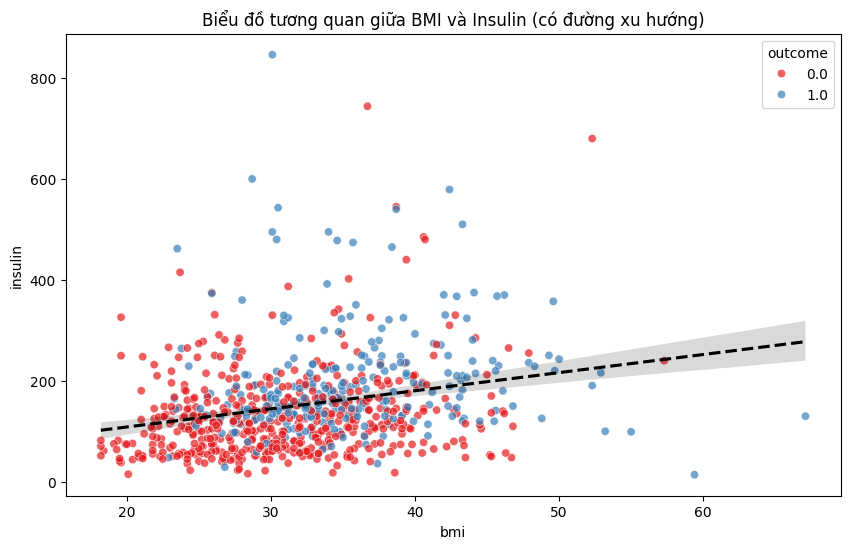

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="bmi",
    y="insulin",
    hue="outcome",
    palette="Set1",
    alpha=0.7,
    ax=ax
)

sns.regplot(
    data=df_clean, 
    x="bmi", 
    y="insulin", 
    scatter=False, 
    color="black", 
    line_kws={"linestyle":"--"}, 
    ax=ax
)

ax.set_title("Biểu đồ tương quan giữa BMI và Insulin (có đường xu hướng)")
plt.show()

### Nhận xét (BMI vs Insulin):
- Đường xu hướng (màu đen nét đứt) hướng lên trên cho thấy **mối tương quan thuận (đồng biến)**: Những người có BMI càng cao (càng béo phì) thì mức Insulin trong máu thường càng cao.
- Những bệnh nhân tiểu đường (chấm đỏ) thường tập trung ở góc trên bên phải (vừa béo phì, vừa có insulin cao - dấu hiệu đặc trưng của hội chứng kháng insulin ở bệnh tiểu đường type 2).

## 2. Tương quan giữa Tuổi (Age) và Insulin

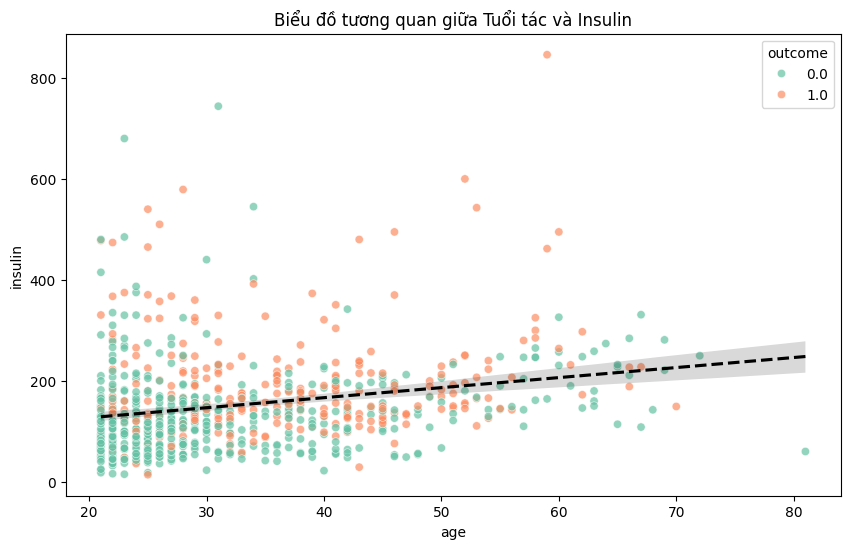

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="age",
    y="insulin",
    hue="outcome",
    palette="Set2",
    alpha=0.7,
    ax=ax
)

sns.regplot(
    data=df_clean, 
    x="age", 
    y="insulin", 
    scatter=False, 
    color="black", 
    line_kws={"linestyle":"--"}, 
    ax=ax
)

ax.set_title("Biểu đồ tương quan giữa Tuổi tác và Insulin")
plt.show()

### Nhận xét (Tuổi vs Insulin):
- Mối tương quan giữa Tuổi và Insulin **yếu hơn rất nhiều** so với BMI hoặc Glucose. Đường xu hướng gần như đi ngang hoặc chỉ hơi nhích nhẹ.
- Dữ liệu tập trung rất đông ở độ tuổi trẻ (20-30 tuổi) với mức insulin đa dạng.
- Điều này cho thấy tuổi tác không phải là yếu tố kích thích trực tiếp làm tăng tiết insulin mạnh như việc lượng đường trong máu (Glucose) hay lượng mỡ trong cơ thể (BMI) tăng cao.

---
## 3. Tổng kết bằng Ma trận tương quan (Correlation Heatmap)


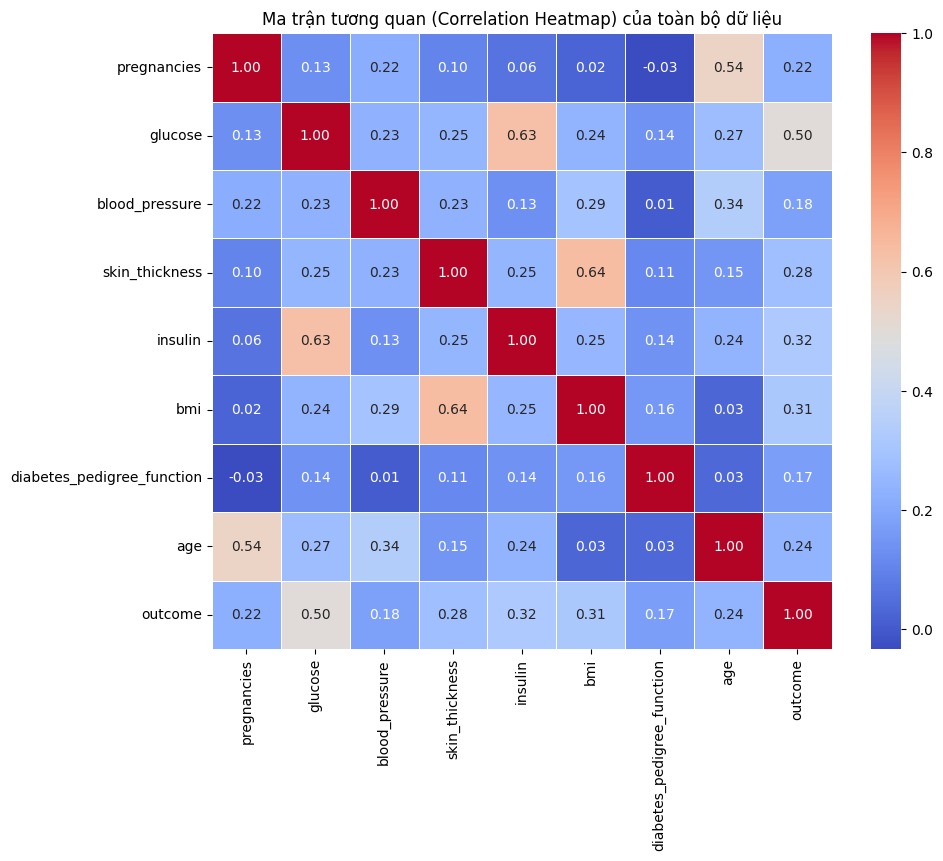

In [10]:
plt.figure(figsize=(10, 8))

corr_matrix = df_clean.corr()

# Vẽ heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,       
    cmap="coolwarm",   
    fmt=".2f",         
    linewidths=0.5
)
plt.title("Ma trận tương quan (Correlation Heatmap) của toàn bộ dữ liệu")
plt.show()

### Phân tích ma trận Tương quan (nhìn vào dòng/cột `insulin`):
1. **`insulin` vs `glucose` (≈ 0.63)**: Tương quan dương khá mạnh. Đây là mối liên hệ mạnh nhất của Insulin.
2. **`insulin` vs `skin_thickness` (≈ 0.25)** và **`bmi` (≈ 0.25)**: Tương quan dương vừa phải. Skin thickness (độ dày nếp gấp da) là một đại lượng đo lượng mỡ tương tự BMI, xác nhận việc béo phì làm tăng Insulin.
3. **`insulin` vs `age` (≈ 0.24)**: Chứng tỏ hai biến này cũng có mối tương quan tương đương vừa phải với nhau.